In [3]:
# i want to see  what coverage of infra red spectra data i have for waka df

import pandas as pd


In [4]:
# loading of waka df
waka_df = pd.read_csv('data/waka_with_CID.csv')
waka_df.sort_values(by= 'CID', inplace= True)
waka_df = waka_df.loc[:, 'CID':]
waka_df.head()

,CID,CAS,Name,Imax,Ci,Di
12,179,513-86-0,acetoin,49.69,0.90,0.76
40,240,100-52-7,benzaldehyde,62.02,1.23,0.69
42,244,100-51-6,benzyl alcohol,30.28,1.49,0.33
89,323,91-64-5,coumarin,26.79,0.68,0.77
90,326,122-03-2,cumin aldehyde,49.53,1.29,0.47


In [5]:
# loading of the infra red spectra data
ir_df = pd.read_csv('data/ir_matrix_df.csv')
ir_df.rename(columns={'cid' : 'CID'}, inplace=True)
print(ir_df.shape)
ir_df.head()

(1837, 880)


,moodifyindex,name of material,cas,CID,500,504,508,512,516,520,...,3964,3968,3972,3976,3980,3984,3988,3992,3996,4000
0,1001676,2-phenylethylamine,64-04-0,1001.0,0.950401,0.945366,0.947563,0.956060,0.967908,0.979700,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1000336,formaldehyde diethyl acetal,462-95-3,10024.0,0.999997,1.000000,1.000000,1.000000,1.000000,0.999999,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,1001568,cuminyl acetate,59230-57-8,100990.0,0.993741,0.994850,0.996246,0.997456,0.998077,0.997772,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,1001053,2-tropical oxathiane,67715-80-4,101010.0,0.993396,0.995152,0.996884,0.998251,0.999149,0.999646,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1001151,"1,4-cineole",470-67-7,10106.0,0.992881,0.995992,0.998024,0.999150,0.999685,0.999902,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [6]:
# Merging 
waka_ir_merge = pd.merge(
    waka_df[['CID', 'Imax']],
    ir_df,
    on='CID',
    how='left'
)
print(f"Merged df shape: {waka_ir_merge.shape}")

Merged df shape: (447, 881)


In [7]:
waka_ir_merge.drop_duplicates(subset='CID', keep='first', inplace=True)
waka_ir_merge.sort_values(by='CID',inplace=True)
waka_ir_merge

,CID,Imax,moodifyindex,name of material,cas,500,504,508,512,516,...,3964,3968,3972,3976,3980,3984,3988,3992,3996,4000
0,179,49.69,1000173.0,acetoin 1% dpg,513-86-0,0.987300,0.992886,0.992749,0.988837,0.982527,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,240,62.02,1000001.0,benzaldehyde,100-52-7,0.998571,0.999424,0.999797,0.999938,0.999984,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
5,244,30.28,1000448.0,benzyl alcohol,100-51-6,0.993289,0.992605,0.992900,0.994048,0.995651,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
6,323,26.79,1000006.0,coumarin,91-64-5,0.992670,0.993482,0.994790,0.996095,0.996886,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
8,326,49.53,1000034.0,cuminic aldehyde,122-03-2,0.999924,0.999862,0.999785,0.999709,0.999649,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442,16070752,48.88,1000200.0,karanal,117933-89-8,0.987294,0.985844,0.985356,0.985622,0.986293,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
443,16204527,59.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
444,19871663,36.61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
445,44153588,24.15,1000677.0,tricyclodecenyl butyrate,113889-23-9,0.999720,0.999869,0.999945,0.999974,0.999974,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [8]:
waka_ir_merge.to_csv('data/waka_ir_spectra.csv', index=False)

In [9]:
waka_ir_merge.shape

(312, 881)

In [10]:
waka_ir_merge.columns

Index(['CID', 'Imax', 'moodifyindex', 'name of material', 'cas', '500', '504',
       '508', '512', '516',
       ...
       '3964', '3968', '3972', '3976', '3980', '3984', '3988', '3992', '3996',
       '4000'],
      dtype='str', length=881)

In [11]:
meta_cols = ['CID', 'name of material'] #identifier columns
meta_df = waka_ir_merge[meta_cols] # merged df with identifier columns 
X_ir = waka_ir_merge.loc[:, '500':] # waka ir features matrix

In [12]:
missing_mask = X_ir.isna().any(axis=1) # binary pandas series with Falses in place od rows with missing IR data, True for missing

print(f"Rows with missing IR values: {missing_mask.sum()}")

Rows with missing IR values: 30


In [13]:
X_ir_complete = X_ir.loc[~missing_mask]

meta_complete = meta_df.loc[~missing_mask]

vY_complete = waka_ir_merge['Imax'][~missing_mask]

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [15]:
# Make sure IR columns are numeric
X_ir_complete = X_ir_complete.astype(float)

# Scale IR spectra before PCA
scaler_ir = StandardScaler()
X_ir_scaled = scaler_ir.fit_transform(X_ir_complete)

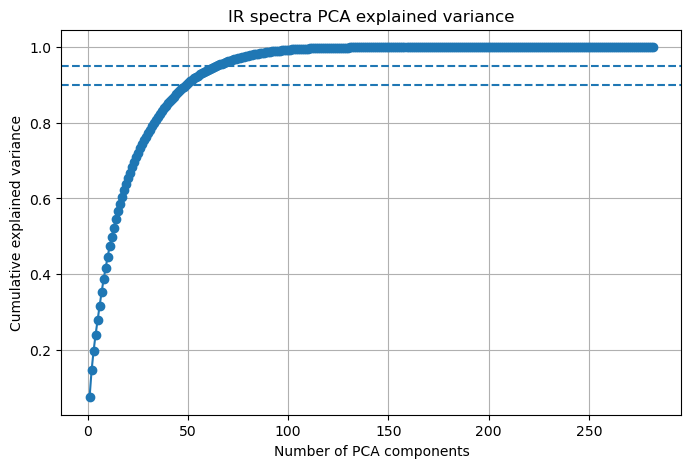

Components for 90% variance: 49
Components for 95% variance: 65


In [16]:
# Fit PCA first without choosing n_components
pca_full = PCA()
X_ir_pca_full = pca_full.fit_transform(X_ir_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(0.90, linestyle='--')
plt.axhline(0.95, linestyle='--')
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("IR spectra PCA explained variance")
plt.grid(True)
plt.show()

n90 = np.argmax(cum_var >= 0.90) + 1
n95 = np.argmax(cum_var >= 0.95) + 1

print(f"Components for 90% variance: {n90}")
print(f"Components for 95% variance: {n95}")

In [19]:
pca_ir = PCA(n_components=0.95)
X_ir_pca = pca_ir.fit_transform(X_ir_scaled)
print(X_ir_pca.shape)

(282, 65)


In [20]:
from xgboost import XGBRegressor

from sklearn.model_selection import GridSearchCV, KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

In [21]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_ir = XGBRegressor(
    objective='reg:absoluteerror',
    random_state=42,
    n_jobs=-1
)

param_grid_ir = {
    'n_estimators': [100, 300, 500],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'reg_lambda': [1, 5, 10],
}

In [22]:
oSearchGridXGB_IR = GridSearchCV(
    estimator=xgb_ir,
    param_grid=param_grid_ir,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

oSearchGridXGB_IR.fit(X_ir_pca, vY_complete)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.9, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 300, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the mor

In [23]:
oSearchGridXGB_IR.best_params_

{'colsample_bytree': 0.9,
 'learning_rate': 0.01,
 'max_depth': 3,
 'n_estimators': 500,
 'reg_lambda': 10,
 'subsample': 1.0}

In [24]:
print("Best parameters:")
print(oSearchGridXGB_IR.best_params_)

print("Best CV MAE:")
print(-oSearchGridXGB_IR.best_score_)

Best parameters:
{'colsample_bytree': 0.9, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'reg_lambda': 10, 'subsample': 1.0}
Best CV MAE:
11.312195324250034


In [25]:
vYPred_xgb_ir = cross_val_predict(
    oSearchGridXGB_IR.best_estimator_,
    X_ir_pca,
    vY_complete,
    cv=cv,
    n_jobs=-1
)

mae_xgb_ir = mean_absolute_error(
    vY_complete,
    vYPred_xgb_ir
)

r2_xgb_ir = r2_score(
    vY_complete,
    vYPred_xgb_ir
)

print(f"mae_xgb_ir: {mae_xgb_ir}")
print(f"r2_xgb_ir: {r2_xgb_ir}")

mae_xgb_ir: 11.318205180607789
r2_xgb_ir: 0.08658298124987251


In [26]:
X13_df = pd.read_csv('data/13features_matrix.csv')
X13_df

,Eig07_AEA_dm_,HTm,Eig09_AEA_ri_,ATS6m,Mor11u,SpDiam_X,Psi_i_0d,SpMaxA_AEA_dm_,P_VSA_v_2,Mor17v,BP,log_vp,vp
0,0.000,2.558,0.000,0.000,-0.533,2.000,0.093,0.742,67.828,-0.193,147.500000,-0.163905,0.685638
1,-1.505,2.523,0.000,0.113,0.078,2.000,0.026,0.373,25.145,-0.042,178.889000,-0.001051,0.997582
2,-1.350,2.180,0.000,0.202,0.290,2.000,0.024,0.344,42.683,-0.055,205.500000,-1.004329,0.099008
3,-0.382,4.265,-0.198,1.040,0.011,2.000,-0.004,0.302,36.145,0.056,299.000000,-3.008774,0.000980
4,-1.000,3.535,-0.489,1.627,-0.409,2.000,-0.004,0.277,25.145,-0.177,153.796459,-1.254028,0.055715
...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,1.451,4.552,1.069,3.017,-1.977,2.000,0.000,0.178,22.000,-0.706,301.520307,-3.410876,0.000388
308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,185.012383,-3.911308,0.000123
309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,185.012383,-3.911308,0.000123
310,1.035,4.363,0.706,2.815,-1.487,1.973,0.000,0.208,36.145,-0.536,297.571641,-3.239050,0.000577


In [33]:
missing_mask.reset_index(drop=True)

0      False
1      False
2      False
3      False
4      False
       ...  
307    False
308     True
309     True
310    False
311     True
Length: 312, dtype: bool

In [34]:
X13_complete = X13_df.loc[~missing_mask.reset_index(drop=True)]
print(X13_complete.shape)

(282, 13)


In [35]:
X13_complete

,Eig07_AEA_dm_,HTm,Eig09_AEA_ri_,ATS6m,Mor11u,SpDiam_X,Psi_i_0d,SpMaxA_AEA_dm_,P_VSA_v_2,Mor17v,BP,log_vp,vp
0,0.000,2.558,0.000,0.000,-0.533,2.000,0.093,0.742,67.828,-0.193,147.500000,-0.163905,0.685638
1,-1.505,2.523,0.000,0.113,0.078,2.000,0.026,0.373,25.145,-0.042,178.889000,-0.001051,0.997582
2,-1.350,2.180,0.000,0.202,0.290,2.000,0.024,0.344,42.683,-0.055,205.500000,-1.004329,0.099008
3,-0.382,4.265,-0.198,1.040,0.011,2.000,-0.004,0.302,36.145,0.056,299.000000,-3.008774,0.000980
4,-1.000,3.535,-0.489,1.627,-0.409,2.000,-0.004,0.277,25.145,-0.177,153.796459,-1.254028,0.055715
...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,0.935,4.434,0.749,2.735,-3.301,1.980,0.000,0.205,11.000,-0.896,274.495652,-2.537005,0.002904
304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,185.012383,-3.911308,0.000123
306,1.118,5.484,0.741,3.338,-1.966,2.000,0.000,0.185,47.145,-0.576,208.888083,-4.065334,0.000086
307,1.451,4.552,1.069,3.017,-1.977,2.000,0.000,0.178,22.000,-0.706,301.520307,-3.410876,0.000388


In [37]:
X_combined = np.hstack([
    X13_complete.values,
    X_ir_pca
])

In [38]:
print(X_combined.shape)

(282, 78)


In [39]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb = XGBRegressor(
    objective='reg:absoluteerror',
    random_state=42,
    n_jobs=-1
)

In [41]:
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.9],
    'min_child_weight': [1, 3, 5],
    'reg_lambda': [1, 5, 10]
}

In [42]:
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_combined, vY_complete)

Fitting 5 folds for each of 2187 candidates, totalling 10935 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.5, 0.7, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], 'min_child_weight': [1, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the mor

In [43]:
print(grid.best_params_)
print(-grid.best_score_)

{'colsample_bytree': 0.5, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 500, 'reg_lambda': 1, 'subsample': 0.7}
8.476836842986277


In [44]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

vYPred = cross_val_predict(
    grid.best_estimator_,
    X_combined,
    vY_complete,
    cv=cv,
    n_jobs=-1
)

mae = mean_absolute_error(
    vY_complete,
    vYPred
)

r2 = r2_score(
    vY_complete,
    vYPred
)

print(f"MAE: {mae:.2f}")
print(f"R2 : {r2:.3f}")

MAE: 8.48
R2 : 0.511


In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    clusters = kmeans.fit_predict(X_ir_pca)

    sil = silhouette_score(
        X_ir_pca,
        clusters
    )

    results.append([k, sil])

results

c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is kno

[[2, 0.28307626795776913],
 [3, 0.1121826395511066],
 [4, 0.12212094599906742],
 [5, 0.09851943612389469],
 [6, 0.09583593013882467],
 [7, 0.09048203995710997],
 [8, 0.13624954740408235],
 [9, 0.08573776789978164],
 [10, 0.03350499104477147]]

<Axes: xlabel='k'>

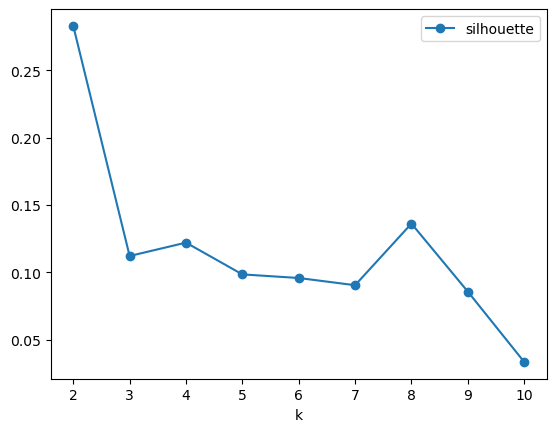

In [46]:
results_df = pd.DataFrame(
    results,
    columns=['k', 'silhouette']
)

results_df.plot(
    x='k',
    y='silhouette',
    marker='o'
)

In [49]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_ir_pca)

c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [50]:
cluster_df = pd.DataFrame({
    'cluster': clusters,
    'Imax': vY_complete
})

cluster_df.groupby('cluster')['Imax'].agg(
    ['count','mean','std']
)

,count,mean,std
cluster,,,
0,225,40.344400,15.905368
1,57,35.355263,13.360758


In [51]:
kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_ir_pca)

cluster_df = pd.DataFrame({
    'cluster': clusters,
    'Imax': vY_complete
})

cluster_stats = (
    cluster_df
    .groupby('cluster')['Imax']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .sort_values('mean')
)

print(cluster_stats)

         count       mean  median        std    min    max
cluster                                                   
3            2   8.930000   8.930   1.612203   7.79  10.07
2           37  36.179189  35.470  13.879522   7.20  62.02
6            2  36.615000  36.615   9.864140  29.64  43.59
7           75  37.129733  40.110  13.200770   6.73  66.44
4            3  39.096667  37.510   9.499902  30.49  49.29
0            2  41.235000  41.235   3.132483  39.02  43.45
1          160  41.416438  39.940  16.676785   2.90  84.97
5            1  51.900000  51.900        NaN  51.90  51.90


c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


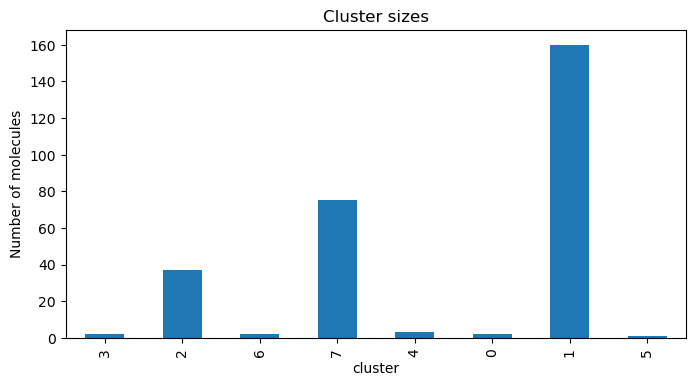

In [52]:
cluster_stats['count'].plot(
    kind='bar',
    figsize=(8,4)
)

plt.ylabel('Number of molecules')
plt.title('Cluster sizes')
plt.show()

In [54]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_ir_pca)

c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [55]:
cluster_df = pd.DataFrame({
    'cluster': clusters,
    'Imax': vY_complete
})

cluster_stats = (
    cluster_df
    .groupby('cluster')['Imax']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .sort_values('mean')
)

print(cluster_stats)

         count       mean  median        std    min    max
cluster                                                   
1           39  35.537436  37.390  15.437650   7.20  67.67
0           76  37.400263  40.430  13.284381   6.73  66.44
3            3  39.096667  37.510   9.499902  30.49  49.29
2          164  41.140671  39.905  16.419007   2.90  84.97


In [ ]:
# the idea with IR spectra didn't waork